# H-006 · Kalman β vs static OLS hedge (trad-z)

Requires frozen `BREAK_STAR` plus H-005 window STARs (`OLS_WINDOW_STAR`, `ADF_WINDOW_STAR`, `ENTRY_Z_STAR`, `Z_WINDOW_STAR`). Bake-off under that stack.

Freeze on fold-val Sharpe (max DD / corr to S1 as secondary). ADF / HL / lag-1 autocorr are **not** freeze inputs. Type `HEDGE_STAR` (`"ols"` or `"kalman"`); if Kalman, also type `KALMAN_DELTA_STAR`.


## 0. Imports & Config


In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s2_coint.report import (
    arm_selection_table,
    fold_table,
    fold_val_metrics,
    full_is_metrics,
    load_star_stack,
    median_sharpe_hint,
    plot_fold_boxplots,
    require_star,
    save_star_stack,
    write_tearsheet_pdf,
)
from backtest.s2_coint.research import (
    ARTIFACTS_DIR,
    DEFAULT_STAR_STACK,
    config_from_stack,
    is_end_for_stack,
    load_s1_weekly,
    frozen_pairs_for_universe,
    load_universe_panels,
    lookbacks_for_bar,
    overlay_kalman_hedge,
    overlay_ols_hedge,
    n_trials_local,
    n_trials_stack,
    register_hypothesis_arms,
    repo_root,
    split_is_oos,
    tearsheet_path,
)
from backtest.s2_coint.runner import run_s2_backtest
from backtest.s2_coint.walkforward import embargo_bars_for_config, make_s2_folds
from strategies.s2_coint.config import S2SimConfig

STAR_PATH = DEFAULT_STAR_STACK
TEARSHEET_DIR = ARTIFACTS_DIR
stack = load_star_stack(STAR_PATH)
# Universe from H-001. PAIRS_STAR is only populated when BOOK_STAR = freeze (H-004);
# otherwise fall back to the ranked frozen book written by H-001.
require_star("UNIVERSE_STAR", stack.get("UNIVERSE_STAR"))
UNIVERSE = str(stack["UNIVERSE_STAR"])
PAIRS_STAR = list(stack.get("PAIRS_STAR") or frozen_pairs_for_universe(UNIVERSE, "1d", root=ROOT))
print("stack keys:", sorted(stack))
print("UNIVERSE", UNIVERSE, "PAIRS", PAIRS_STAR)


stack keys: ['ADF_WINDOW_STAR', 'BAR_STAR', 'BOOK_STAR', 'BREAK_STAR', 'ENTRY_Z_STAR', 'OLS_WINDOW_STAR', 'UNIVERSE_STAR', 'Z_WINDOW_STAR']
UNIVERSE E PAIRS ['CCI|AMT', 'SBAC|CCI', 'SBRA|VTR', 'NNN|O', 'NNN|WPC', 'PLD|TRNO']


## 1. Load frozen panel / PAIRS_STAR


In [2]:
require_star("BAR_STAR", stack.get("BAR_STAR"))
for key in ("BREAK_STAR", "OLS_WINDOW_STAR", "ADF_WINDOW_STAR", "ENTRY_Z_STAR", "Z_WINDOW_STAR"):
    require_star(key, stack.get(key))
BAR = str(stack["BAR_STAR"])
train, full = load_universe_panels(UNIVERSE, BAR, PAIRS_STAR, root=ROOT)
lb = lookbacks_for_bar(
    BAR,
    ols_days=int(stack["OLS_WINDOW_STAR"]),
    z_days=int(stack["Z_WINDOW_STAR"]),
    adf_days=int(stack["ADF_WINDOW_STAR"]),
)
# Start from OLS panel with frozen windows; Kalman arm overlays in the bake-off.
train = overlay_ols_hedge(
    train,
    ols_window=lb["ols_window"],
    z_window=lb["z_window"],
    hl_window=lb["hl_window"],
    adf_window=lb["adf_window"],
)
full = overlay_ols_hedge(
    full,
    ols_window=lb["ols_window"],
    z_window=lb["z_window"],
    hl_window=lb["hl_window"],
    adf_window=lb["adf_window"],
)
is_end = is_end_for_stack(stack, full if BAR == "1h" else train)
if BAR == "1d":
    is_panel, oos_panel = train.copy(), full.loc[pd.to_datetime(full["date"]) > is_end].copy()
else:
    is_panel, oos_panel = split_is_oos(full, is_end=is_end)
s1_weekly = load_s1_weekly(ROOT)
print("bar", BAR, "is_end", is_end, "IS rows", len(is_panel), "OOS rows", len(oos_panel))
print("windows", {k: lb[k] for k in ("ols_window", "z_window", "adf_window")})
is_panel.head()


bar 1d is_end 2021-12-31 00:00:00 IS rows 32407 OOS rows 7038
windows {'ols_window': 504, 'z_window': 90, 'adf_window': 252}


,date,pair_id,ticker_y,ticker_x,open_y,high_y,low_y,close_y,open_x,high_x,low_x,close_x,alpha,beta,spread,z,half_life,adf_pvalue,variance_jump
0,1994-10-18,NNN|O,NNN,O,12.250,12.250,12.125,12.250,7.751938,7.812500,7.630814,7.751938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1994-10-19,NNN|O,NNN,O,12.250,12.375,12.125,12.375,7.812500,8.478682,7.812500,8.418120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1994-10-20,NNN|O,NNN,O,12.250,12.500,12.250,12.375,8.539244,8.781492,8.478682,8.478682,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1994-10-21,NNN|O,NNN,O,12.375,12.375,12.250,12.250,8.478682,8.539244,8.296996,8.357558,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1994-10-24,NNN|O,NNN,O,12.250,12.375,12.250,12.375,8.357558,8.539244,8.175872,8.175872,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Attach Kalman hedge columns (OLS panel already loaded)


In [3]:
lb = lookbacks_for_bar(
    BAR,
    ols_days=int(stack["OLS_WINDOW_STAR"]),
    z_days=int(stack["Z_WINDOW_STAR"]),
    adf_days=int(stack["ADF_WINDOW_STAR"]),
)
KALMAN_DELTA_GRID = (1e-4, 1e-5, 1e-6, 1e-7)
CHAN_SANITY_DELTA = 1e-3


def _hedge_diag(panel, label):
    g = panel.groupby("pair_id")
    return pd.DataFrame(
        {
            "median_adf": g["adf_pvalue"].median(),
            "median_hl": g["half_life"].median(),
            "lag1_ac": g["spread"].apply(lambda s: float(s.astype(float).autocorr(lag=1))),
        }
    ).assign(arm=label)


kf_panels = {}
rows = [_hedge_diag(is_panel, "ols")]
for d in (CHAN_SANITY_DELTA,) + KALMAN_DELTA_GRID:
    p = overlay_kalman_hedge(
        is_panel.copy(),
        burn_in=lb["kalman_burn_in"],
        z_window=lb["z_window"],
        hl_window=lb["hl_window"],
        adf_window=lb["adf_window"],
        delta=d,
    )
    if d in KALMAN_DELTA_GRID:
        kf_panels[d] = p
    rows.append(_hedge_diag(p, f"kalman_{d:g}"))

diag = pd.concat(rows)
print("ADF/HL/autocorr diagnostic (not a freeze input). Expect lag1_ac and HL to rise toward OLS as δ shrinks.")
print("Chan δ=1e-4 is sanity contrast only — not a freeze candidate.")
diag


ADF/HL/autocorr diagnostic (not a freeze input). Expect lag1_ac and HL to rise toward OLS as δ shrinks.
Chan δ=1e-4 is sanity contrast only — not a freeze candidate.


,median_adf,median_hl,lag1_ac,arm
pair_id,,,,
CCI|AMT,2.479870e-01,17.636212,0.973532,ols
NNN|O,3.019353e-01,17.354029,0.980980,ols
NNN|WPC,4.494933e-01,22.351895,0.980209,ols
PLD|TRNO,1.696809e-01,12.913950,0.976331,ols
SBAC|CCI,2.861181e-01,21.974320,0.988966,ols
SBRA|VTR,3.548586e-01,27.142733,0.990525,ols
CCI|AMT,1.935955e-26,0.277753,0.119387,kalman_0.001
NNN|O,2.522169e-24,0.247039,-0.006879,kalman_0.001
NNN|WPC,5.359431e-26,0.240548,-0.092209,kalman_0.001


## 3. Walk-forward folds


In [4]:
dates = pd.DatetimeIndex(pd.to_datetime(is_panel["date"])).sort_values().unique()
folds = make_s2_folds(dates, n_folds=3, embargo_bars=embargo_bars_for_config(bar=BAR))
fold_table(folds)


,fold_id,train_start,train_end,n_train,embargo_start,embargo_end,val_start,val_end,n_val
0,1,1994-10-18,2001-07-23,1707,2001-07-24,2001-07-30,2001-07-31,2008-05-23,1713
1,2,1994-10-18,2008-05-16,3420,2008-05-19,2008-05-23,2008-05-27,2015-03-16,1713
2,3,1994-10-18,2015-03-09,5133,2015-03-10,2015-03-16,2015-03-17,2021-12-31,1713


## 4. Fold-val metrics (validation only)


In [5]:
HYP_ID = "H-006"
cfg_ols = config_from_stack(stack, hedge="ols")
cfg_kf = config_from_stack(stack, hedge="kalman")
configs_hedge = {"ols": cfg_ols}
for _d in kf_panels:
    configs_hedge[f"kalman_{_d:g}"] = cfg_kf
register_hypothesis_arms(HYP_ID, list(configs_hedge.keys()), overwrite=True)
parts = [fold_val_metrics(is_panel, folds, {"ols": cfg_ols}, hyp_id=HYP_ID, s1_weekly=s1_weekly)]
for d, panel in kf_panels.items():
    arm = f"kalman_{d:g}"
    parts.append(fold_val_metrics(panel, folds, {arm: cfg_kf}, hyp_id=HYP_ID, s1_weekly=s1_weekly))
fold_df = pd.concat(parts, ignore_index=True)
full_is_parts = [full_is_metrics(is_panel, {"ols": cfg_ols}, hyp_id=HYP_ID, s1_weekly=s1_weekly)]
for d, panel in kf_panels.items():
    arm = f"kalman_{d:g}"
    full_is_parts.append(full_is_metrics(panel, {arm: cfg_kf}, hyp_id=HYP_ID, s1_weekly=s1_weekly))
full_is_df = pd.concat(full_is_parts, ignore_index=True)
fold_df


,arm,fold_id,ann_sharpe,max_drawdown,corr_to_s1,psr,dsr_local,dsr_stack,n_trials_local,n_trials_stack,n_days,n_entries,pct_z_finite,median_hl_bars,median_hl_sessions
0,ols,1,0.354933,-0.079799,NaN,1.000000,1.000000,1.000000,1,18,1713,38,0.922866,20.801357,20.801357
1,ols,2,0.236797,-0.035116,NaN,1.000000,1.000000,1.000000,1,18,1713,62,0.939880,19.476919,19.476919
2,ols,3,0.280501,-0.020011,-0.115552,1.000000,1.000000,1.000000,1,18,1713,49,1.000000,22.342500,22.342500
3,kalman_0.0001,1,-0.721385,-0.630854,NaN,0.000000,0.000000,0.000000,1,18,1713,687,0.985835,0.574305,0.574305
4,kalman_0.0001,2,-0.228447,-0.132517,NaN,0.000000,0.000000,0.000000,1,18,1713,803,0.987915,0.571821,0.571821
5,kalman_0.0001,3,-1.299711,-0.211817,-0.178312,0.000000,0.000000,0.000000,1,18,1713,896,1.000000,0.493967,0.493967
6,kalman_1e-05,1,-0.501176,-0.513874,NaN,0.000000,0.000000,0.000000,1,18,1713,440,0.985835,1.598170,1.598170
7,kalman_1e-05,2,-0.542650,-0.193503,NaN,0.000000,0.000000,0.000000,1,18,1713,572,0.987915,1.592803,1.592803
8,kalman_1e-05,3,-0.431438,-0.168598,-0.154428,0.000000,0.000000,0.000000,1,18,1713,608,1.000000,1.403326,1.403326
9,kalman_1e-06,1,-0.333163,-0.455460,NaN,0.000000,0.000000,0.000000,1,18,1713,248,0.985835,4.222943,4.222943


## 5. Boxplots (do not assign STAR here)


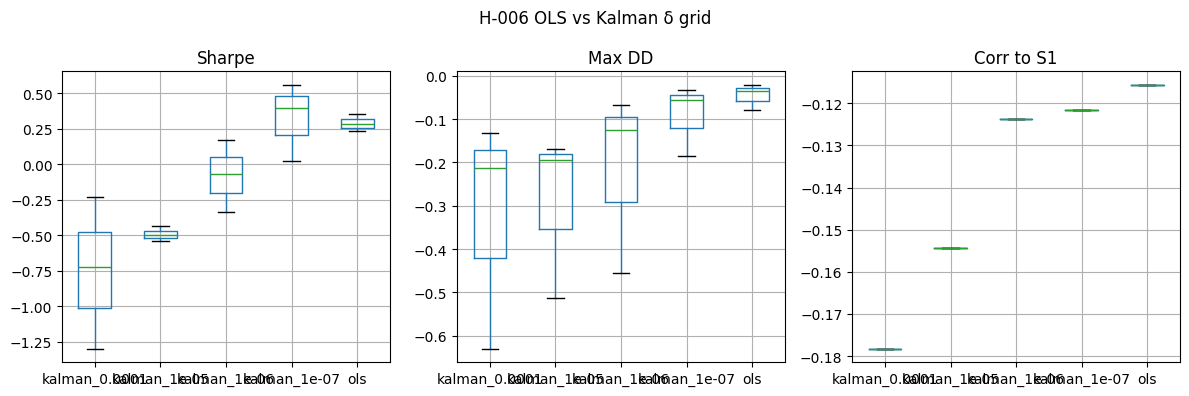

median-Sharpe hint (commentary only): kalman_1e-07


,arm,median_val_sharpe,full_is_sharpe,max_drawdown,corr_to_s1,n_folds,median_psr,median_dsr_local,median_dsr_stack,full_is_psr,full_is_dsr_local,full_is_dsr_stack
0,kalman_0.0001,-0.721385,-0.435089,-0.211817,-0.178312,3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,kalman_1e-05,-0.501176,-0.233756,-0.193503,-0.154428,3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,kalman_1e-06,-0.070555,0.001185,-0.125356,-0.123685,3,0.002173,0.002173,0.000002,0.538974,0.538974,0.039869
3,kalman_1e-07,0.395970,0.491240,-0.056390,-0.121592,3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,ols,0.280501,0.329922,-0.035116,-0.115552,3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
plot_fold_boxplots(fold_df, title="H-006 OLS vs Kalman δ grid")
plt.show()
print("median-Sharpe hint (commentary only):", median_sharpe_hint(fold_df))
display(arm_selection_table(fold_df, full_is_df))


## 6. Type `HEDGE_STAR` (and `KALMAN_DELTA_STAR` if Kalman) then save


In [9]:
HEDGE_STAR = "kalman"  # TODO after fold-val review: "ols" or "kalman"
KALMAN_DELTA_STAR = 1e-7  # TODO if Kalman: 1e-5, 1e-6, or 1e-7 (not 1e-4)
require_star("HEDGE_STAR", HEDGE_STAR)
stack["HEDGE_STAR"] = HEDGE_STAR
if HEDGE_STAR == "kalman":
    require_star("KALMAN_DELTA_STAR", KALMAN_DELTA_STAR)
    dstar = float(KALMAN_DELTA_STAR)
    if not any(abs(dstar - d) < 1e-12 for d in KALMAN_DELTA_GRID):
        raise ValueError(f"KALMAN_DELTA_STAR must be one of {KALMAN_DELTA_GRID}, got {KALMAN_DELTA_STAR!r}")
    stack["KALMAN_DELTA_STAR"] = dstar
else:
    stack["KALMAN_DELTA_STAR"] = None
save_star_stack(STAR_PATH, stack)
print("wrote", STAR_PATH, "HEDGE_STAR", HEDGE_STAR, "KALMAN_DELTA_STAR", stack.get("KALMAN_DELTA_STAR"))


wrote C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s2_coint\artifacts\s2_star_stack.json HEDGE_STAR kalman KALMAN_DELTA_STAR 1e-07


## 7. Sealed OOS once


In [10]:
require_star("HEDGE_STAR", HEDGE_STAR)
oos_use = oos_panel
if HEDGE_STAR == "kalman":
    require_star("KALMAN_DELTA_STAR", KALMAN_DELTA_STAR)
    oos_use = overlay_kalman_hedge(
        oos_panel.copy(),
        burn_in=lb["kalman_burn_in"],
        z_window=lb["z_window"],
        hl_window=lb["hl_window"],
        adf_window=lb["adf_window"],
        delta=float(KALMAN_DELTA_STAR),
    )
n_loc = n_trials_local(configs_hedge)
n_stk = n_trials_stack(HYP_ID, configs_hedge)
oos = run_s2_backtest(
    oos_use, config_from_stack(stack), s1_weekly=s1_weekly,
    n_trials_local=n_loc,
    n_trials_stack=n_stk,
)

print(oos.metrics)
arm_label = HEDGE_STAR if HEDGE_STAR == "ols" else f"kalman_{float(KALMAN_DELTA_STAR):g}"
write_tearsheet_pdf(
    tearsheet_path("H-006", arm_label), oos.returns, title=f"H-006 {arm_label} sealed OOS",
    n_trials_local=n_loc,
    n_trials_stack=n_stk,
)

print("tearsheet", tearsheet_path("H-006", arm_label))


{'ann_sharpe': 0.33845854589906355, 'max_drawdown': -0.03151103659958898, 'n_days': 1173, 'psr': 1.0, 'dsr_local': 1.0, 'dsr_stack': 1.0, 'skew': 0.39938390719941524, 'excess_kurtosis': 10.796503230950599, 'n_trials_local': 5, 'n_trials_stack': 22, 'corr_to_s1': 0.019404530777615142}
tearsheet C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s2_coint\artifacts\H-006_kalman_1e-07.pdf


## 8. Notes for next hyp


H-007 spread ADX/RSI filter is next. TA-Lib required for that notebook. Leave `HEDGE_STAR`, `KALMAN_DELTA_STAR`, `BREAK_STAR`, and window STARs frozen. If 1h is ever re-opened, Kalman Q should be ≈ Q_day/6 so calendar adaptation matches (do not session-scale δ on 1d).
